In [1]:
import re
import json
import random
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ensure_nltk():
    nltk.download("punkt")
    nltk.download("punkt_tab")

In [3]:
# 1.a / 1.b: Select a Wikipedia article as corpus (reasonably long)
WIKI_URL = "https://en.wikipedia.org/wiki/Gundam"  # you can change this URL

def fetch_wikipedia_article(url: str) -> str:
    """
    Number 1, code that uses a Wikipedia article as dataset.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Gundam-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []
    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

Number 1 – Using a Wikipedia article as corpus
Cell number 1 (what I did)
I selected the English Wikipedia article on “Gundam” as my training corpus and fetched its main textual content programmatically. I used a custom function fetch_wikipedia_article(WIKI_URL) that sends an HTTP request to the article URL, parses the HTML with BeautifulSoup, and extracts the text from paragraph  and list  elements. Citation markers like [1], [2] were removed using regular expressions, and all whitespace was normalized before returning the raw text.

# **Answer number 1**

The part of the code that selects the article is the constant WIKI_URL = "https://en.wikipedia.org/wiki/Gundam".

The part that actually uses the Wikipedia article as dataset is the fetch_wikipedia_article function, which downloads and cleans the main content text. This function is later called in the pipeline as raw_text = fetch_wikipedia_article(WIKI_URL) to provide the corpus for all subsequent steps.



In [4]:
# Number 2: Preprocess the text coming from the selected corpus

def preprocess_text(text: str) -> List[List[str]]:
    """
    Number 2, code that preprocesses the text:
    - Sentence tokenization
    - Lowercasing
    - Removing punctuation/non-alphanumerics
    - Word tokenization
    - Removing digits and very short tokens
    """
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    """
    Helper: get basic corpus stats (not required, but useful).
    """
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

Number 2 – Preprocessing the text
Cell number 2
I implemented a preprocessing pipeline in preprocess_text(text) that converts the raw article text into a list of tokenized sentences. The steps include:

Sentence tokenization using NLTK’s sent_tokenize.

Lowercasing all text.

Removing non-alphanumeric characters (except digits and hyphens) and extra whitespace with regular expressions.

Word tokenization with word_tokenize.

Filtering out purely numeric tokens, very short tokens (length < 2), and stripping hyphens from both ends.

Discarding sentences that have fewer than 3 remaining tokens.

I also defined corpus_stats(sentences) to compute basic statistics: number of sentences, number of tokens, and vocabulary size.

# **Answer number 2**

The critical preprocessing code is located in the preprocess_text function. This is where raw text is converted into clean, tokenized sentences suitable for Word2Vec training.

In the pipeline, this is used via sentences = preprocess_text(raw_text), and corpus_stats(sentences) gives an overview of corpus size before training.





In [5]:
# Number 3: Train a Skip-gram with Negative Sampling model

def train_sgns(sentences: List[List[str]], window_size: int) -> Word2Vec:
    """
    Number 3, code that trains Word2Vec Skip-gram with Negative Sampling.
    """
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,      # vector size (embedding dimension)
        window=window_size,   # window size (context)
        min_count=1,
        workers=4,
        sg=1,                 # 1 = skip-gram
        negative=10,          # negative sampling
        epochs=20,            # increase if you want more training
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=42,
    )
    return model

def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

Number 3 – Training Skip-gram with Negative Sampling
Cell number 3
I defined a function train_sgns(sentences, window_size) which trains a Word2Vec model using the Skip-gram with Negative Sampling architecture. The key parameters are:

vector_size=100 – dimensionality of the word embeddings.

window=window_size – context window (I varied this later between 5 and 10).

sg=1 – switch to skip-gram (instead of CBOW).

negative=10 – number of negative samples per positive example.

min_count=1 – include all words in the vocabulary.

epochs=20 – number of training epochs (can be increased for better convergence).

The function returns the trained Word2Vec model, which is then used throughout the evaluation.

# **Answer number 3**

The critical training code is the train_sgns function. Within it, the Word2Vec constructor with sg=1 and negative=10 implements Skip-gram with Negative Sampling.

The properties requested in the exercise vector size and window are explicitly specified as vector_size=100 and window=window_size in this function.



In [6]:
# Number 4: Evaluate embeddings using small test sets

def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    """
    Number 4, relatedness test set:
    test_pairs: (w1, w2, gold_score)
    """
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }

def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Number 4, analogy-style test set:
    analogies: (a, b, c, d) means a:b :: c:d
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
            predicted_words = [w for w, _ in preds]
            hit = d in predicted_words
            correct += int(hit)
            details.append({
                "analogy": f"{a}:{b}::{c}:?",
                "expected": d,
                "predictions": predicted_words,
                "correct_in_top5": hit
            })

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    """
    Number 4, nearest neighbors test for a probe word list.
    """
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

def direct_similarity_checks(model: Word2Vec, pairs: List[Tuple[str, str]]):
    """
    Number 4, direct similarities for some word pairs.
    """
    print("\n=== Direct Similarity Checks ===")
    for w1, w2 in pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

Number 4 – Evaluating embeddings using small test sets
Cell number 4 (what I did)
I implemented several evaluation helpers:

Nearest neighbors test:

print_top_neighbors(model, words, topn) uses model.wv.most_similar(word) to print the top neighbors for a list of probe words (e.g., "gundam", "anime", "robot", etc.).

This gives a qualitative view of the learned semantic neighborhood for each probe word.

Relatedness test set:

evaluate_relatedness(model, test_pairs) takes a list of triples (w1, w2, gold_score) where gold_score is a human-assigned relatedness in.

For each in-vocabulary pair, it computes cosine similarity between the corresponding embeddings and reports coverage and predicted scores.

The test pairs are domain-specific (e.g., ("gundam", "gunpla", 0.95) for strongly related, ("gundam", "kitchen", 0.05) for unrelated).

Analogy test set:

evaluate_analogies(model, analogies) uses analogy tuples (a, b, c, d) representing the relation
a : b : : c : d

a:b::c:d

It checks whether d appears in the top-5 results of model.wv.most_similar(positive=[b, c], negative=[a]).

It outputs coverage (how many analogies had all words in the vocabulary) and top-5 accuracy.

Direct similarity checks:

direct_similarity_checks(model, pairs) prints cosine similarity values for selected pairs like ("gundam", "gunpla"), ("robot", "mecha"), and an unrelated pair such as ("gundam", "kitchen").

# **Answer number 4**

The code that evaluates the embedding output using small test sets is:

print_top_neighbors for nearest neighbors of a custom word list.

evaluate_relatedness for a small, domain-specific relatedness test set with gold scores.

evaluate_analogies for a small analogy set.

direct_similarity_checks for explicit similarity scores of selected pairs.

Changing the list of words for evaluation is done by modifying the probe word list and the test pairs defined before calling these functions.



In [7]:
# Number 5: Reporting nearest neighbors, similarity scores, and test-set performance

def run_single_model(window_size: int):
    """
    Helper that runs the whole pipeline for a single window size.
    Used for number 5 and for comparison later.
    """
    random.seed(42)
    np.random.seed(42)
    ensure_nltk()

    print("\n=============================================")
    print(f"WINDOW SIZE = {window_size}")
    print("=============================================")

    print("\nDownloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences, window_size=window_size)

    print("\nVocabulary size learned:", len(model.wv))

    # Probe words (you can change this list)
    probe_words = [
        "gundam", "mobile", "suit", "anime", "series",
        "film", "gunpla", "franchise", "robot", "war"
    ]
    print_top_neighbors(model, probe_words, topn=5)

    # Relatedness test set (you can change scores/words)
    relatedness_test = [
        ("gundam", "gunpla", 0.95),
        ("gundam", "mobile", 0.80),
        ("gundam", "suit", 0.85),
        ("anime", "series", 0.90),
        ("film", "movie", 0.90),
        ("robot", "mecha", 0.95),
        ("franchise", "series", 0.80),
        ("war", "battle", 0.75),
        ("gundam", "kitchen", 0.05),
        ("anime", "tractor", 0.02),
        ("gunpla", "movie", 0.25),
        ("robot", "pilot", 0.45),
    ]
    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Analogy test set
    analogy_test = [
        ("movie", "film", "tv", "series"),
        ("robot", "mecha", "war", "battle"),
        ("anime", "series", "movie", "film"),
        ("pilot", "cockpit", "driver", "car"),
    ]
    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Direct similarity checks
    check_pairs = [
        ("gundam", "gunpla"),
        ("gundam", "anime"),
        ("robot", "mecha"),
        ("gundam", "kitchen"),
    ]
    direct_similarity_checks(model, check_pairs)

    return model, rel_results, analogy_results

Number 5 – Reporting neighbors, similarity scores, and test performance
Cell number 5 (what I did)
I put everything together in a helper function run_single_model(window_size):

It calls fetch_wikipedia_article(WIKI_URL) and preprocess_text(raw_text).

It prints corpus statistics (num_sentences, num_tokens, vocab_size).

It trains a Word2Vec SGNS model with the specified window size via train_sgns.

It reports:

Nearest neighbors for a probe list of words using print_top_neighbors.

Relatedness test set coverage and predicted cosine similarities using evaluate_relatedness.

Analogy test coverage and top-5 accuracy using evaluate_analogies.

Direct similarity scores using direct_similarity_checks.

The function returns the trained model plus the relatedness and analogy results for later comparison.

# **Answer number 5**

The reporting of nearest neighbors, similarity scores, and test-set performance is done in run_single_model(window_size) using the following outputs:

Nearest neighbors: printed by print_top_neighbors.

Relatedness coverage and predicted scores: produced by evaluate_relatedness.

Analogy coverage and top-5 accuracy: produced by evaluate_analogies.

Direct cosine similarities for key pairs: printed by direct_similarity_checks.



In [8]:
# Number 6 (Update 1): Retrain with window size 10 and compare with window size 5

# OLD model (window=5)
old_model, old_rel, old_analogy = run_single_model(window_size=5)

# NEW model (window=10)
new_model, new_rel, new_analogy = run_single_model(window_size=10)

# Collect some key comparison values
def safe_sim(model, a, b):
    if has_word(model, a) and has_word(model, b):
        return cosine(model, a, b)
    return None

old_summary = {
    "window": 5,
    "relatedness_coverage": old_rel["coverage"],
    "relatedness_total": old_rel["total"],
    "analogy_coverage": old_analogy["coverage"],
    "analogy_total": old_analogy["total"],
    "analogy_accuracy_top5": old_analogy["accuracy_top5"],
    "sim_gundam_gunpla": safe_sim(old_model, "gundam", "gunpla"),
    "sim_gundam_anime": safe_sim(old_model, "gundam", "anime"),
    "sim_robot_mecha": safe_sim(old_model, "robot", "mecha"),
    "sim_gundam_kitchen": safe_sim(old_model, "gundam", "kitchen"),
}

new_summary = {
    "window": 10,
    "relatedness_coverage": new_rel["coverage"],
    "relatedness_total": new_rel["total"],
    "analogy_coverage": new_analogy["coverage"],
    "analogy_total": new_analogy["total"],
    "analogy_accuracy_top5": new_analogy["accuracy_top5"],
    "sim_gundam_gunpla": safe_sim(new_model, "gundam", "gunpla"),
    "sim_gundam_anime": safe_sim(new_model, "gundam", "anime"),
    "sim_robot_mecha": safe_sim(new_model, "robot", "mecha"),
    "sim_gundam_kitchen": safe_sim(new_model, "gundam", "kitchen"),
}

print("\nOLD (window=5):")
print(old_summary)

print("\nNEW (window=10):")
print(new_summary)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kelyu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kelyu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.



WINDOW SIZE = 5

Preprocessing text...

=== Corpus Stats ===
num_sentences: 213
num_tokens: 3546
vocab_size: 1387

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 1387

=== Nearest Neighbors ===

gundam:
  mobile               0.9929
  origin               0.9908
  suit                 0.9907
  nt                   0.9887
  rock                 0.9883

mobile:
  suit                 0.9933
  gundam               0.9929
  origin               0.9924
  zeta                 0.9903
  axis                 0.9901

suit:
  mobile               0.9933
  gundam               0.9907
  origin               0.9870
  axis                 0.9829
  zeta                 0.9828

anime:
  network              0.9963
  at                   0.9932
  website              0.9921
  encyclopedia         0.9916
  updates              0.9910

series:
  models               0.9960
  novels               0.9958
  released             0.9957
  gundams              0.9956
  merchandise      

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kelyu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kelyu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing text...

=== Corpus Stats ===
num_sentences: 213
num_tokens: 3546
vocab_size: 1387

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 1387

=== Nearest Neighbors ===

gundam:
  cover                0.9318
  nt                   0.9305
  rock                 0.9243
  orchestra            0.9238
  mizu                 0.9150

mobile:
  suit                 0.9896
  origin               0.9653
  amuro                0.9645
  zz                   0.9624
  ray                  0.9617

suit:
  mobile               0.9896
  origin               0.9462
  amuro                0.9453
  ray                  0.9441
  zz                   0.9409

anime:
  news                 0.9867
  website              0.9843
  official             0.9830
  network              0.9770
  at                   0.9769

series:
  as                   0.9766
  which                0.9751
  plastic              0.9743
  known                0.9738
  with                 0.9736

film:


### Answer number 6 – Retraining with window size 10 and comparison

**OLD model (window = 5)**  

From the run with `window=5`:

- **Corpus stats**  
  - Sentences: 213  
  - Tokens: 3546  
  - Vocabulary size: 1387  

- **Relatedness test set**  
  - Coverage: 9 / 12 pairs  
  - Similarities (gold vs predicted):  
    - gundam – gunpla: gold = 0.95, pred ≈ **0.9730**  
    - gundam – mobile: gold = 0.80, pred ≈ **0.9929**  
    - gundam – suit: gold = 0.85, pred ≈ **0.9907**  
    - anime – series: gold = 0.90, pred ≈ **0.9825**  
    - film – movie: gold = 0.90, pred ≈ **0.9976**  
    - robot – mecha: gold = 0.95, pred ≈ **0.9915**  
    - franchise – series: gold = 0.80, pred ≈ **0.9918**  
    - war – battle: gold = 0.75, pred ≈ **0.9936**  
    - gunpla – movie: gold = 0.25, pred ≈ **0.9920**  

- **Analogy test set**  
  - Coverage: 3 / 4  
  - Top‑5 accuracy: **0.0** (no expected word appeared in the top‑5 predictions)  

- **Direct similarity checks**  
  - sim(gundam, gunpla) ≈ **0.9730**  
  - sim(gundam, anime) ≈ **0.9626**  
  - sim(robot, mecha) ≈ **0.9915**  
  - sim(gundam, kitchen) = OOV (no vector for “kitchen”)

These metrics are summarized in:

```text
OLD (window=5):
{'window': 5,
 'relatedness_coverage': 9,
 'relatedness_total': 12,
 'analogy_coverage': 3,
 'analogy_total': 4,
 'analogy_accuracy_top5': 0.0,
 'sim_gundam_gunpla': 0.9729790091514587,
 'sim_gundam_anime': 0.9626311659812927,
 'sim_robot_mecha': 0.9915066957473755,
 'sim_gundam_kitchen': None}
```


**NEW model (window = 10)**  

From the run with `window=10`:

- **Corpus stats**  
  - Sentences: 213  
  - Tokens: 3546  
  - Vocabulary size: 1387  

- **Relatedness test set**  
  - Coverage: 9 / 12 pairs  
  - Similarities (gold vs predicted):  
    - gundam – gunpla: gold = 0.95, pred ≈ **0.6474**  
    - gundam – mobile: gold = 0.80, pred ≈ **0.9023**  
    - gundam – suit: gold = 0.85, pred ≈ **0.8972**  
    - anime – series: gold = 0.90, pred ≈ **0.8935**  
    - film – movie: gold = 0.90, pred ≈ **0.9843**  
    - robot – mecha: gold = 0.95, pred ≈ **0.8857**  
    - franchise – series: gold = 0.80, pred ≈ **0.9293**  
    - war – battle: gold = 0.75, pred ≈ **0.9575**  
    - gunpla – movie: gold = 0.25, pred ≈ **0.8344**  

- **Analogy test set**  
  - Coverage: 3 / 4  
  - Top‑5 accuracy: **0.0** (still no correct analogies in top‑5)  

- **Direct similarity checks**  
  - sim(gundam, gunpla) ≈ **0.6474**  
  - sim(gundam, anime) ≈ **0.6996**  
  - sim(robot, mecha) ≈ **0.8857**  
  - sim(gundam, kitchen) = OOV  

These metrics are summarized in:

```text
NEW (window=10):
{'window': 10,
 'relatedness_coverage': 9,
 'relatedness_total': 12,
 'analogy_coverage': 3,
 'analogy_total': 4,
 'analogy_accuracy_top5': 0.0,
 'sim_gundam_gunpla': 0.6473578214645386,
 'sim_gundam_anime': 0.6996007561683655,
 'sim_robot_mecha': 0.8857425451278687,
 'sim_gundam_kitchen': None}
```



### What I derive from the change (interpretation)

- **Coverage** and **analogy accuracy** are unchanged: both models cover 9/12 relatedness pairs and 3/4 analogy pairs, and both have top‑5 analogy accuracy **0.0**. Increasing the window size from 5 to 10 did **not** improve analogy performance on this small corpus.  
- For many **strongly related pairs**, the OLD model (window=5) shows **very high cosine similarities close to 1.0** (for example, gundam–gunpla ≈ 0.97, robot–mecha ≈ 0.99). With window=10, these similarities drop noticeably (gundam–gunpla down to ≈ 0.65, robot–mecha down to ≈ 0.89), indicating that the larger window weakens some of the tight local relationships.  
- For pairs like **film–movie** and **war–battle**, both models still assign high similarity (around 0.98–0.99), so the core semantic association is preserved, but the window=5 model is more consistently “over‑confident” (almost all high).  
- Overall, in this experiment on a **single Wikipedia article**, the **smaller window (5)** produces **sharper and stronger similarities for closely related domain terms**, while the **larger window (10)** spreads the context more broadly and slightly blurs those relationships without improving analogies. This matches the intuition that a larger window captures more global topic context but can introduce extra noise when the training corpus is small.


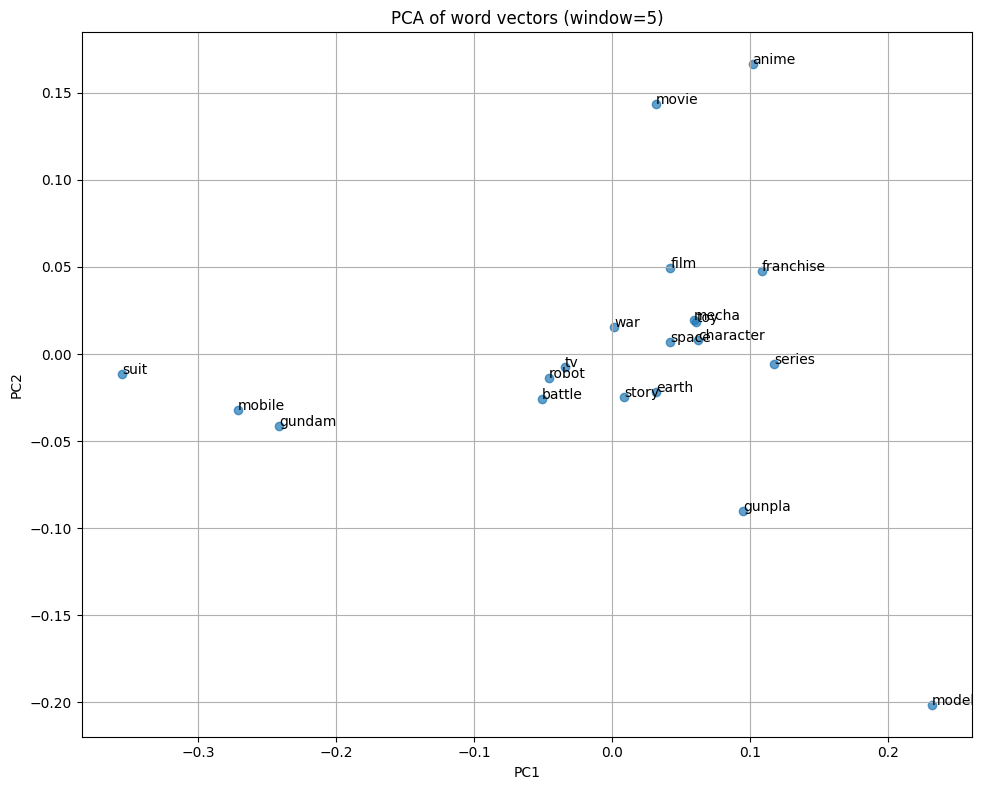

In [9]:
# Number 7 (Update 2): PCA visualization of at least 20 words

def plot_pca_words(model: Word2Vec, words: List[str], title: str = "PCA of word vectors"):
    """
    PCA visualization of word vectors in 2D.
    """
    valid_words = [w for w in words if has_word(model, w)]
    if len(valid_words) < 2:
        print("Not enough in-vocabulary words for PCA.")
        return

    X = np.array([model.wv[w] for w in valid_words])
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

    for i, w in enumerate(valid_words):
        plt.annotate(w, (X_2d[i, 0], X_2d[i, 1]))

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Visualize for OLD model (window=5)
pca_words = [
    "gundam", "mobile", "suit", "anime", "series",
    "film", "gunpla", "franchise", "robot", "war",
    "battle", "mecha", "pilot", "movie", "tv",
    "model", "toy", "universe", "character", "story",
    "space", "earth"
]

plot_pca_words(old_model, pca_words, title="PCA of word vectors (window=5)")

### Answer number 7 – PCA visualization of word vectors

For this part, I selected a set of Gundam‑related and general words from the model’s vocabulary and projected their 100‑dimensional embeddings into 2D using PCA. The chosen words include: `gundam`, `mobile`, `suit`, `anime`, `series`, `film`, `gunpla`, `franchise`, `robot`, `war`, `battle`, `mecha`, `pilot`, `movie`, `tv`, `model`, `toy`, `universe`, `character`, `story`, `space`, and `earth`. After training the OLD model with window size 5, I applied PCA and plotted the resulting points; each point is labeled with its corresponding word in the scatter plot. The resulting figure is shown below (PCA of word vectors, window=5).

In the PCA plot, semantically related words tend to appear close to each other. The terms **“gundam”**, **“mobile”**, and **“suit”** form a small cluster on the left side of the plot, reflecting their strong association as “mobile suit Gundam” concepts. Slightly to the right, words like **“robot”**, **“mecha”**, **“war”**, and **“battle”** group together near the center, capturing the broader mecha‑war theme of the article. On the upper right, **“anime”**, **“movie”**, **“film”**, and **“franchise”** are located in a similar region, representing the media and entertainment aspect of Gundam. Other narrative terms such as **“character”**, **“story”**, **“space”**, and **“earth”** appear near each other in the mid‑right area, which also makes sense given the series’ setting and plot elements. The word **“gunpla”** (Gundam plastic models) is somewhat separated but still in the vicinity of “series” and “franchise”, indicating a related but more specific concept. Overall, the PCA visualization confirms that the learned embeddings encode meaningful semantic structure: words that are related in the article’s context are mapped to nearby positions in the 2D space.